# Customer Churn Prediction & Explainable Retention Intelligence

**Internship-level ML project**

This notebook implements an end-to-end customer churn workflow:
- Data cleaning and EDA
- Leakage-safe train/test split
- One-hot preprocessing
- Decision Tree, Random Forest and XGBoost
- Stratified 5-fold cross-validation
- Hyperparameter tuning
- Accuracy, Precision, Recall, F1 and ROC-AUC
- ROC and Precision-Recall curves
- Feature importance
- SHAP explainability
- Complete pipeline serialization
- New-customer prediction
- Churn risk segmentation
- Retention recommendations


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Place the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Missing Values:


,missing_values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate Rows:
0


In [4]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:",
      df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nCleaned dataset:")
print(df.info())


Missing TotalCharges after conversion: 11

Cleaned dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str   

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:


Churn
0    73.463013
1    26.536987
Name: percentage, dtype: float64

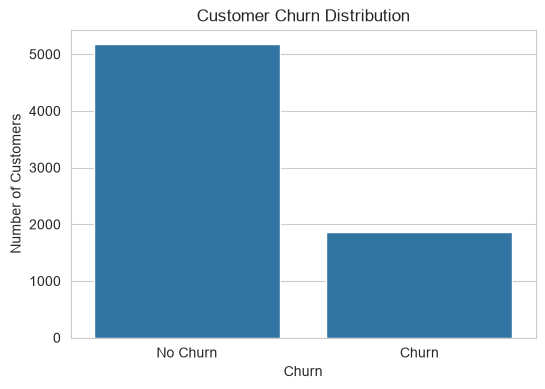

In [5]:
# ============================================================
# 5. TARGET DISTRIBUTION
# ============================================================

print(df["Churn"].value_counts())

print("\nChurn Percentage:")
display(
    (df["Churn"].value_counts(normalize=True) * 100)
    .rename("percentage")
)

plt.figure(figsize=(6, 4))
sns.countplot(x=df["Churn"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.show()


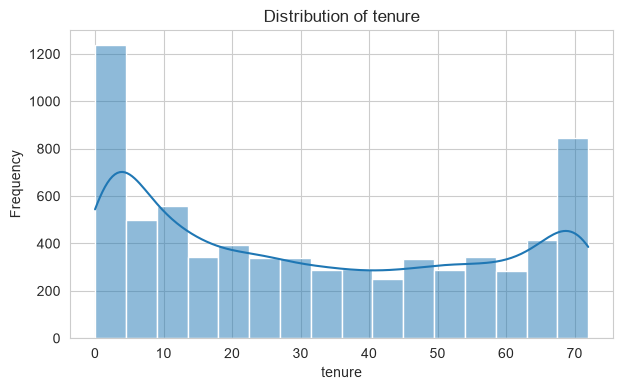

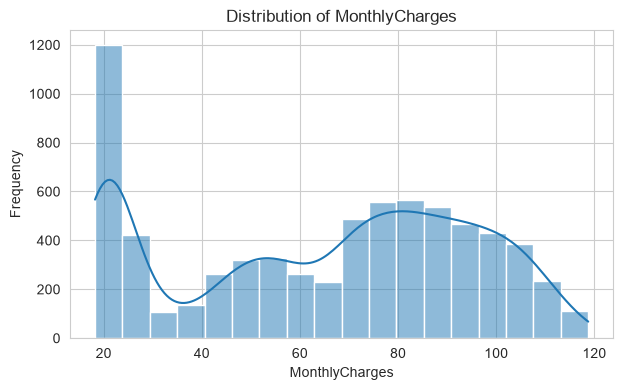

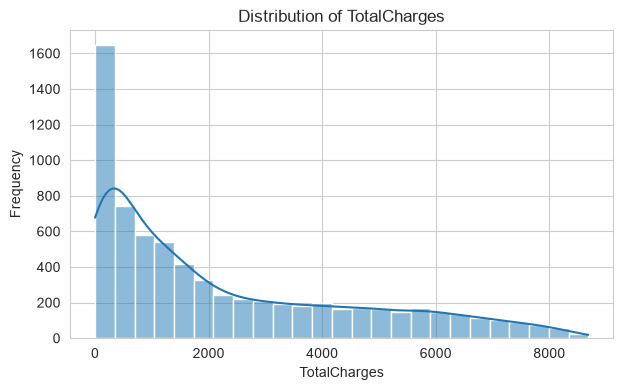

In [6]:
# ============================================================
# 6. NUMERICAL FEATURE ANALYSIS
# ============================================================

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


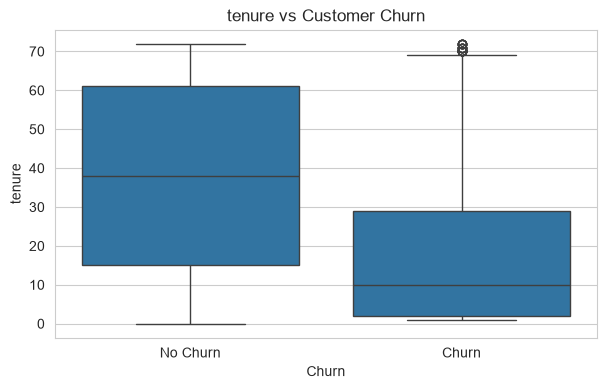

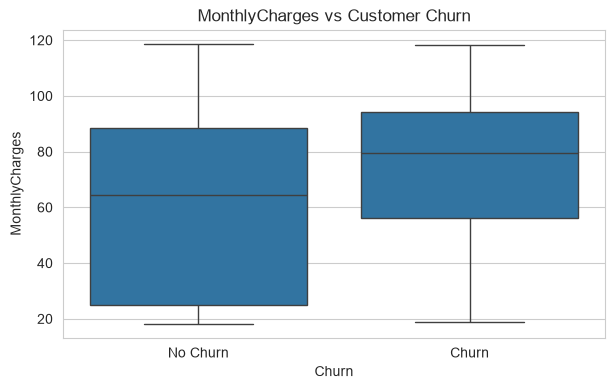

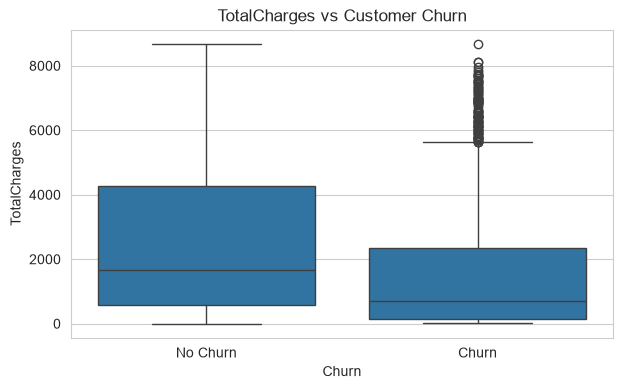

In [7]:
# ============================================================
# 7. CHURN VS NUMERICAL VARIABLES
# ============================================================

for column in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=column)
    plt.title(f"{column} vs Customer Churn")
    plt.xticks([0, 1], ["No Churn", "Churn"])
    plt.show()


Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


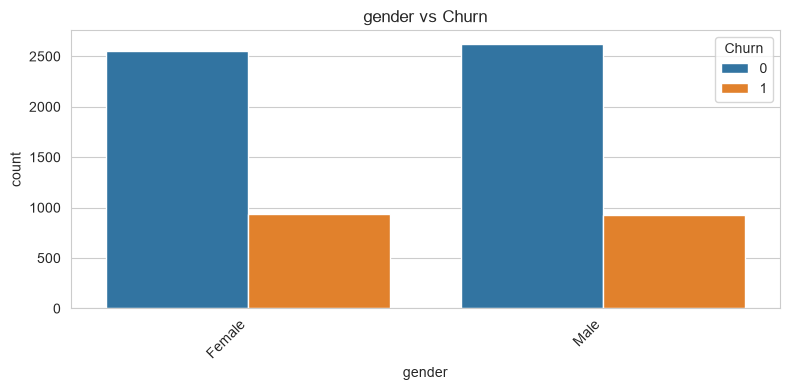

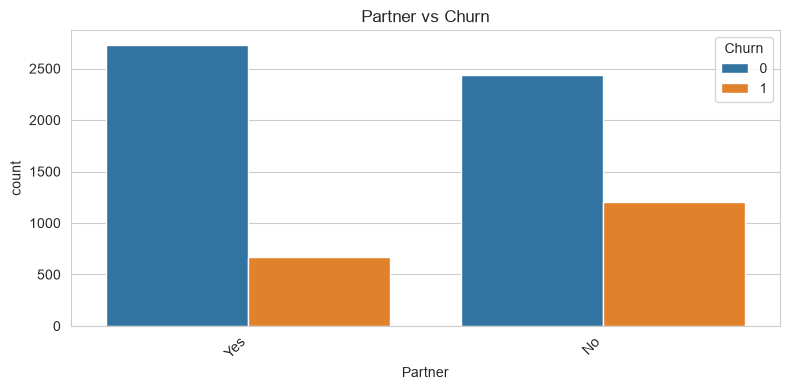

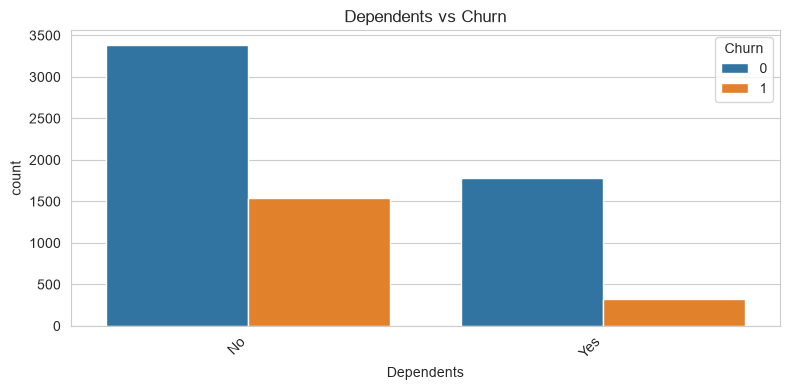

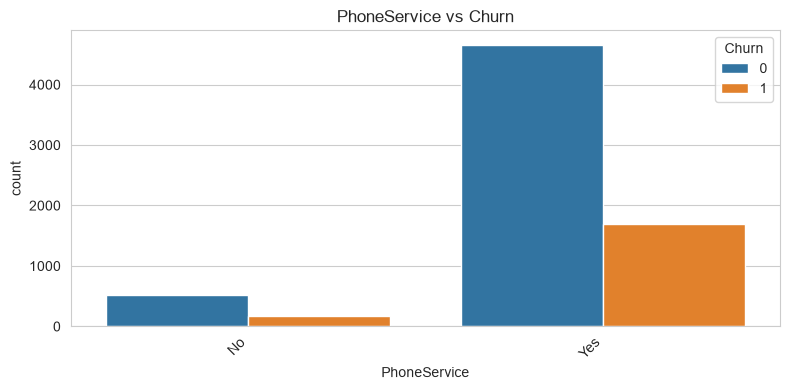

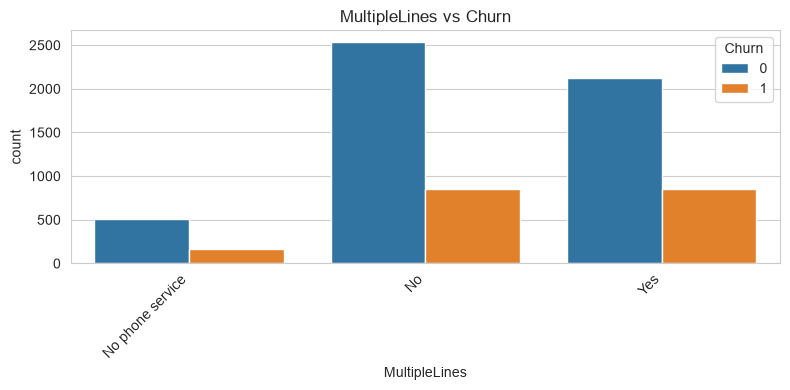

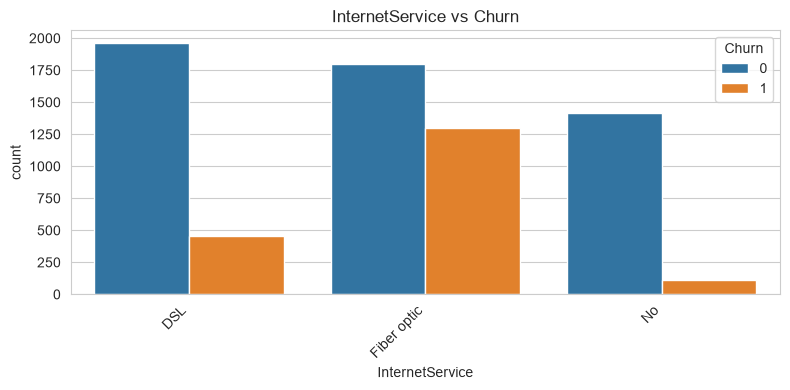

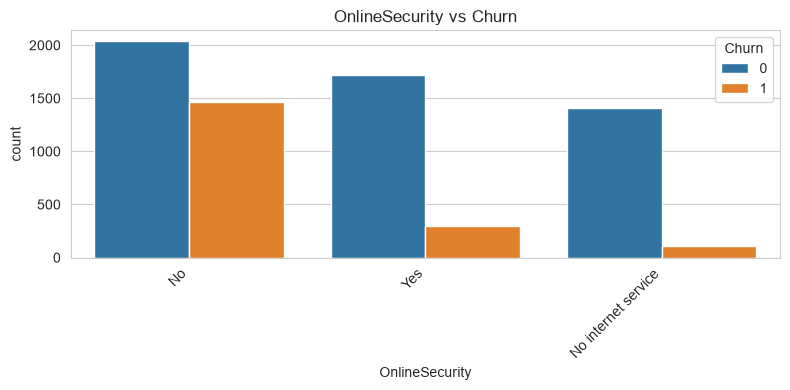

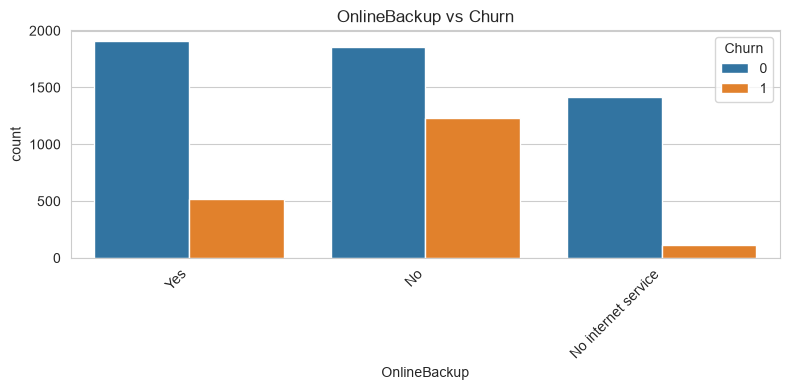

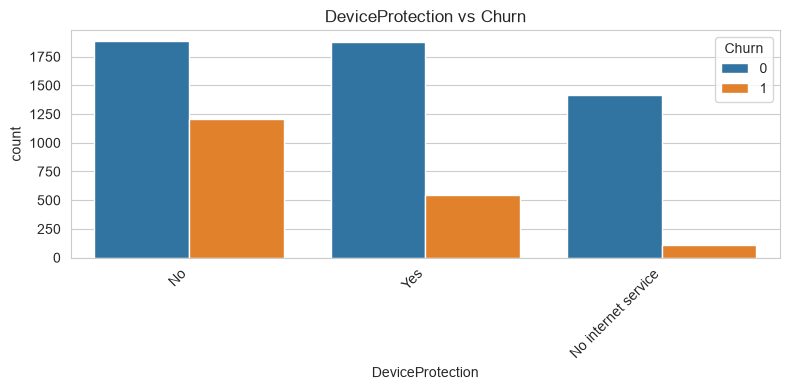

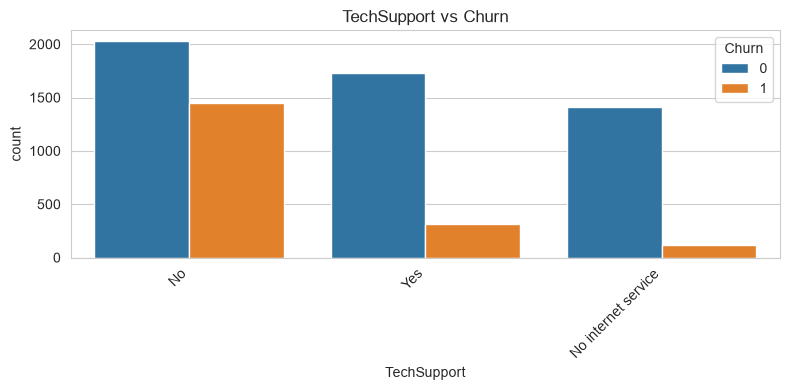

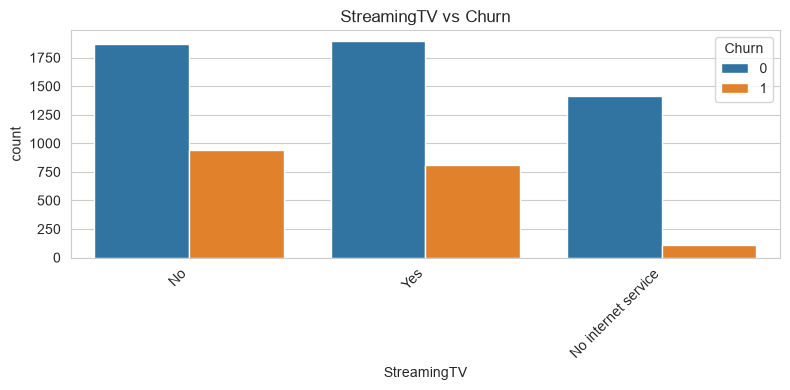

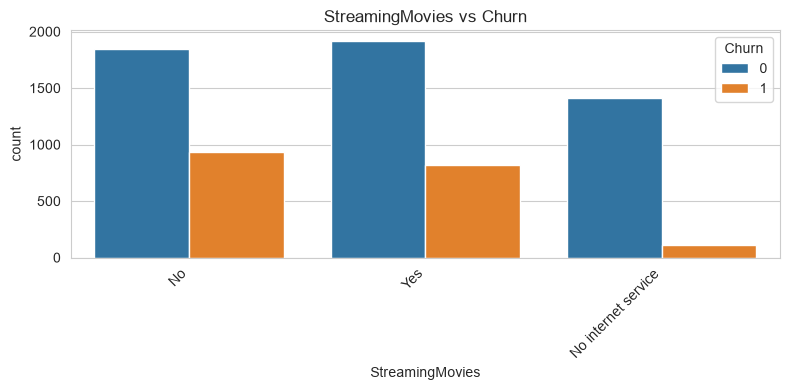

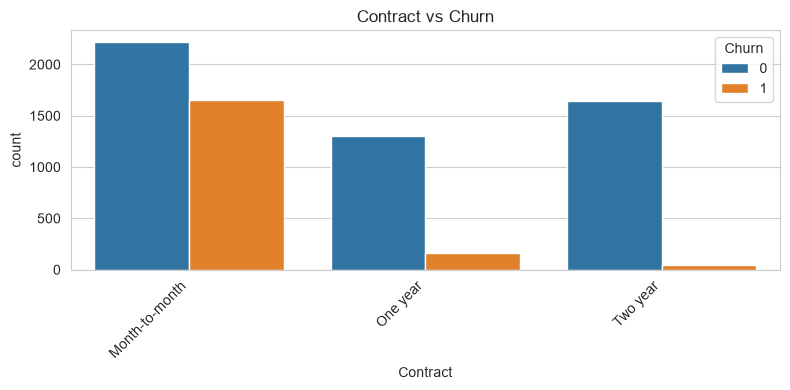

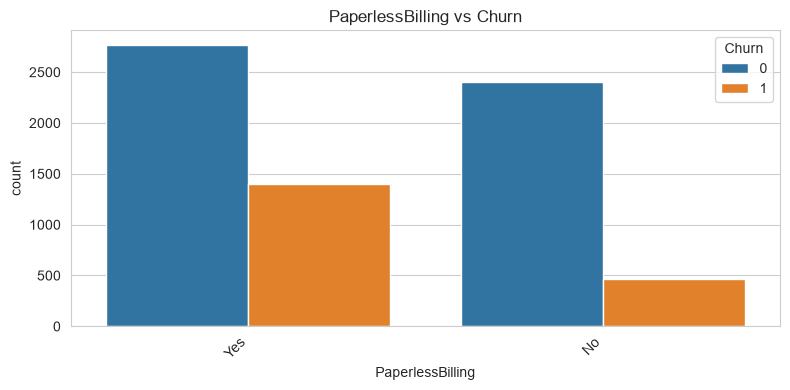

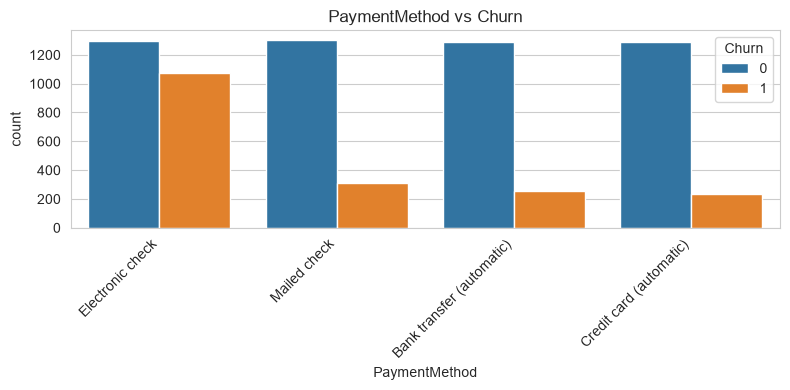

In [8]:
# ============================================================
# 8. CATEGORICAL FEATURE ANALYSIS
# ============================================================

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

for column in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, hue="Churn")
    plt.title(f"{column} vs Churn")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


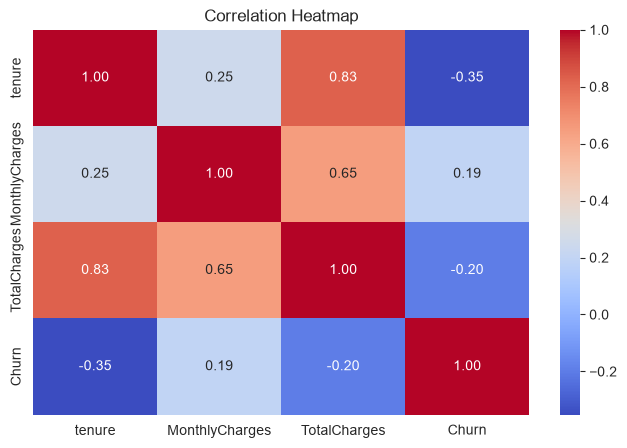

In [9]:
# ============================================================
# 9. CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

correlation_matrix = df[
    numerical_features + ["Churn"]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


In [10]:
# ============================================================
# 10. FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (7043, 19)
Target shape: (7043,)


In [11]:
# ============================================================
# 11. FEATURE TYPES
# ============================================================

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [12]:
# ============================================================
# 12. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())


Training data: (5634, 19)
Testing data: (1409, 19)

Training target distribution:


Churn
0    4139
1    1495
Name: count, dtype: int64


Testing target distribution:


Churn
0    1035
1     374
Name: count, dtype: int64

In [13]:
# ============================================================
# 13. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created.")


Preprocessor created.


## Model evaluation strategy

The project uses **StratifiedKFold** so that the churn/non-churn class distribution is preserved across folds. Hyperparameter tuning uses **ROC-AUC** as the primary selection metric because churn data is imbalanced and accuracy alone can be misleading.


In [14]:
# ============================================================
# 14. STRATIFIED CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [15]:
# ============================================================
# 15. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_probability)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


In [16]:
# ============================================================
# 16. DECISION TREE
# ============================================================

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

dt_results = evaluate_model(
    decision_tree_pipeline,
    X_test,
    y_test,
    "Decision Tree"
)


Decision Tree
Accuracy : 0.7346
Precision: 0.5000
Recall   : 0.4733
F1 Score : 0.4863
ROC-AUC  : 0.6514

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.83      0.82      1035
       Churn       0.50      0.47      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [17]:
# ============================================================
# 17. RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

rf_params = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}

Best CV ROC-AUC:
0.8466328449861524


In [18]:
# ============================================================
# 18. RANDOM FOREST EVALUATION
# ============================================================

best_rf = rf_search.best_estimator_

rf_results = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)


Tuned Random Forest
Accuracy : 0.7566
Precision: 0.5277
Recall   : 0.7888
F1 Score : 0.6324
ROC-AUC  : 0.8447

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [19]:
# ============================================================
# 19. XGBOOST PIPELINE
# ============================================================

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


In [20]:
# ============================================================
# 20. XGBOOST HYPERPARAMETER TUNING
# ============================================================

xgb_params = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_search.best_score_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost Parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}

Best CV ROC-AUC:
0.8500469209929349


In [21]:
# ============================================================
# 21. XGBOOST EVALUATION
# ============================================================

best_xgb = xgb_search.best_estimator_

xgb_results = evaluate_model(
    best_xgb,
    X_test,
    y_test,
    "Tuned XGBoost"
)


Tuned XGBoost
Accuracy : 0.8041
Precision: 0.6667
Recall   : 0.5241
F1 Score : 0.5868
ROC-AUC  : 0.8485

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [22]:
# ============================================================
# 22. MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    dt_results,
    rf_results,
    xgb_results
]).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost,0.804116,0.666667,0.524064,0.586826,0.848486
1,Tuned Random Forest,0.756565,0.527728,0.788770,0.632369,0.844670
2,Decision Tree,0.734564,0.500000,0.473262,0.486264,0.651352


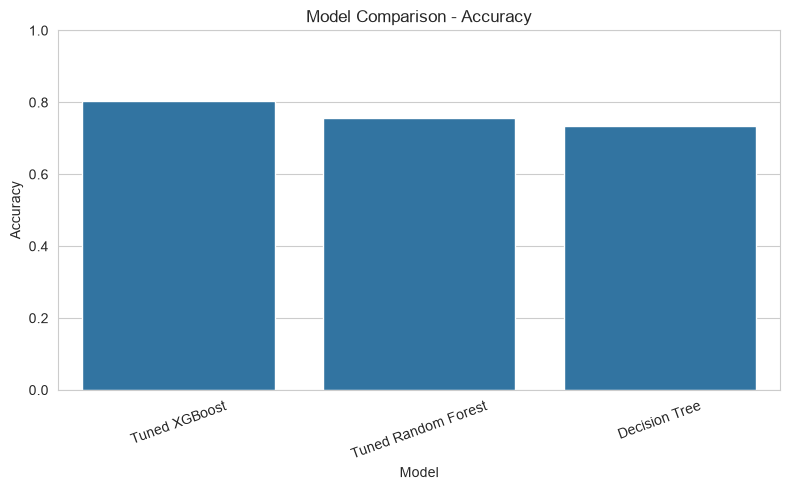

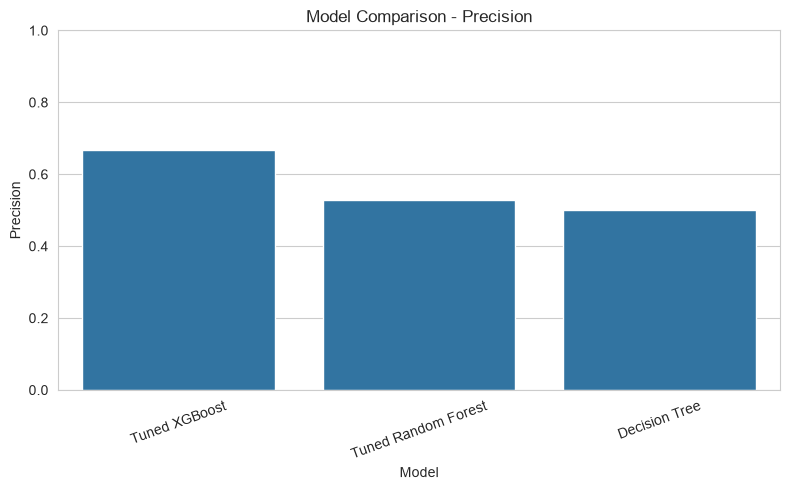

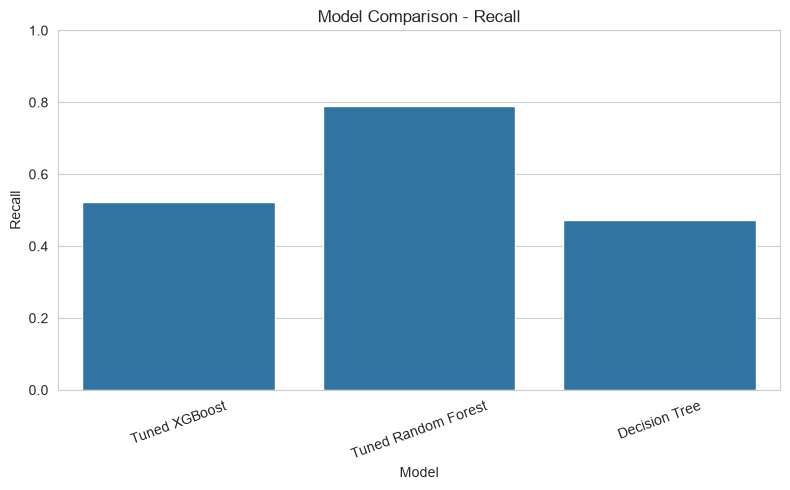

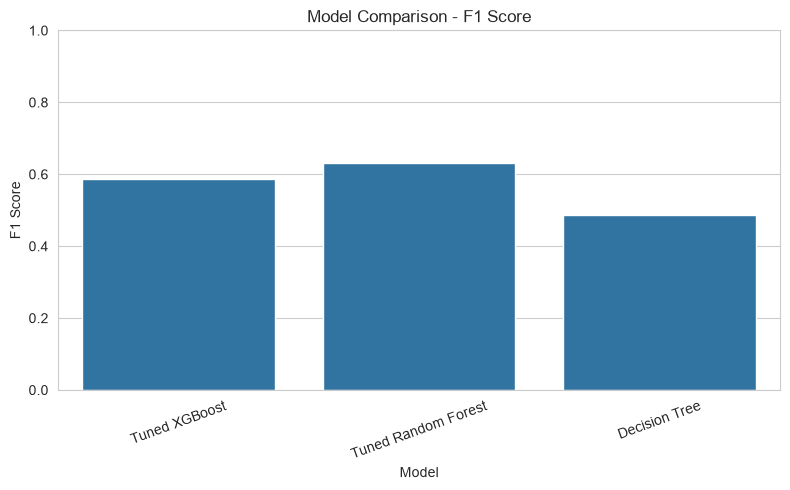

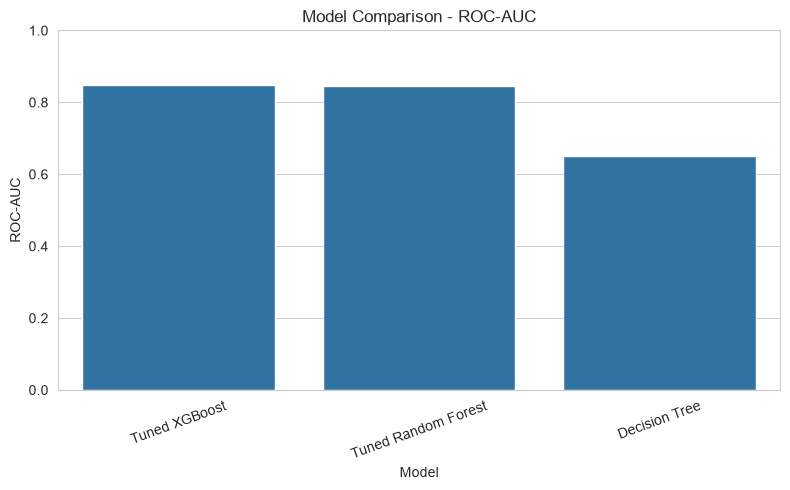

In [23]:
# ============================================================
# 23. MODEL COMPARISON VISUALIZATION
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=results,
        x="Model",
        y=metric
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xticks(rotation=20)
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()


In [24]:
# ============================================================
# 24. SELECT BEST MODEL
# ============================================================

model_objects = {
    "Decision Tree": decision_tree_pipeline,
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb
}

best_model_name = results.iloc[0]["Model"]
best_model = model_objects[best_model_name]

print("Best Model:")
print(best_model_name)

print("\nBest Model Metrics:")
display(
    results[results["Model"] == best_model_name]
)


Best Model:
Tuned XGBoost

Best Model Metrics:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost,0.804116,0.666667,0.524064,0.586826,0.848486


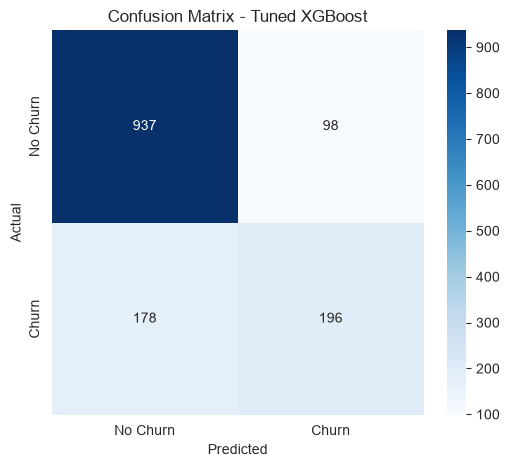

In [25]:
# ============================================================
# 25. CONFUSION MATRIX
# ============================================================

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()


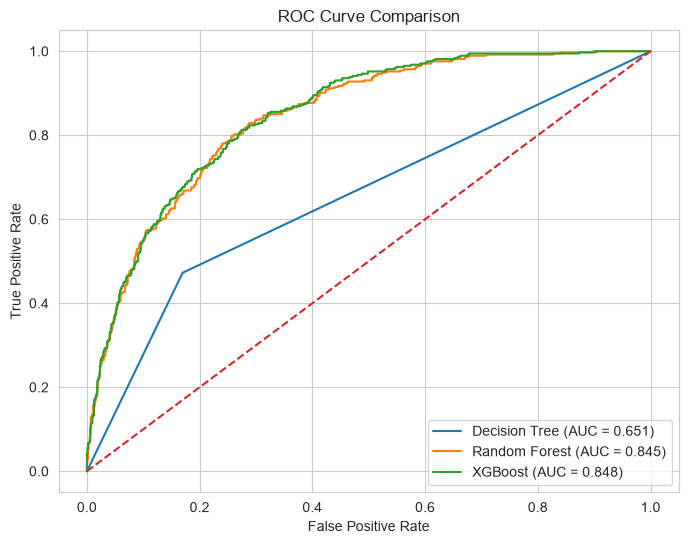

In [26]:
# ============================================================
# 26. ROC CURVE
# ============================================================

plt.figure(figsize=(8, 6))

model_list = {
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for name, model in model_list.items():

    probabilities = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


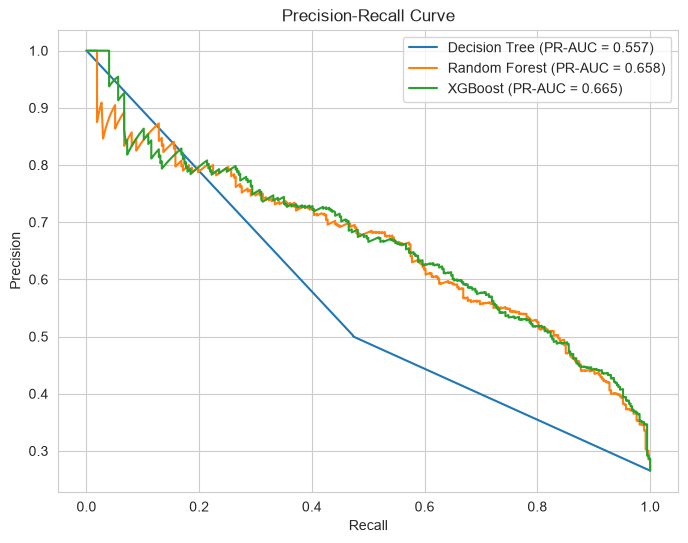

In [27]:
# ============================================================
# 27. PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(8, 6))

for name, model in model_list.items():

    probabilities = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    pr_auc = auc(recall, precision)

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


,Feature,Importance
6,categorical__InternetService_Fiber optic,0.127897
21,categorical__Contract_Two year,0.125679
10,categorical__OnlineBackup_No internet service,0.090869
16,categorical__StreamingTV_No internet service,0.088569
20,categorical__Contract_One year,0.083724
14,categorical__TechSupport_No internet service,0.057158
24,categorical__PaymentMethod_Electronic check,0.054538
12,categorical__DeviceProtection_No internet service,0.043353
27,numerical__tenure,0.040611
7,categorical__InternetService_No,0.040438


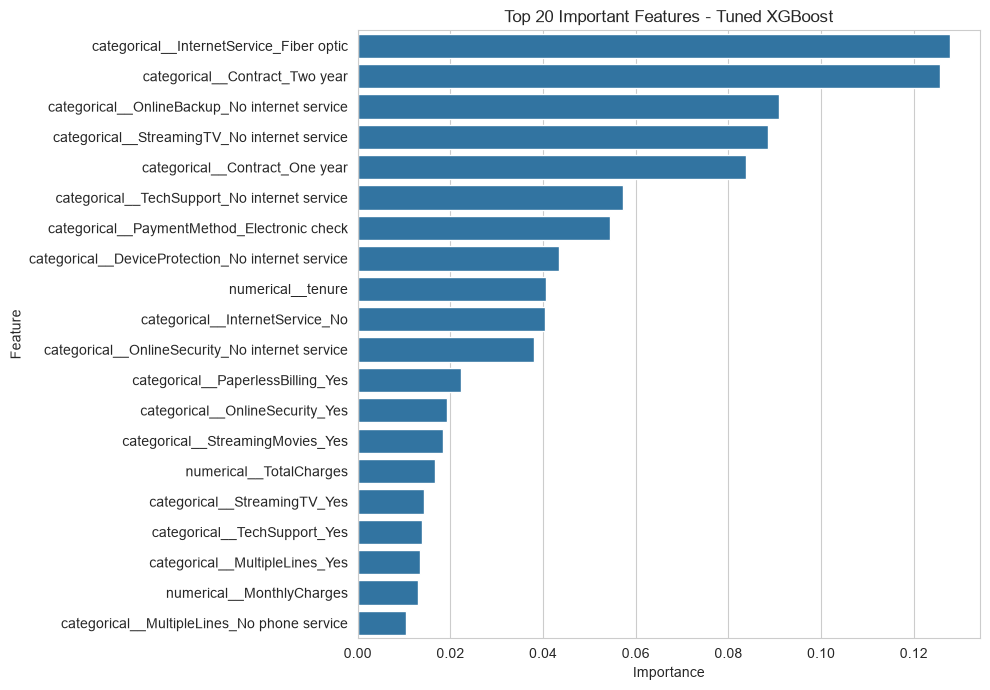

In [28]:
# ============================================================
# 28. FEATURE IMPORTANCE
# ============================================================

if best_model_name != "Decision Tree":

    classifier = best_model.named_steps["classifier"]
    fitted_preprocessor = best_model.named_steps["preprocessor"]

    feature_names = (
        fitted_preprocessor.get_feature_names_out()
    )

    importances = classifier.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(
        by="Importance",
        ascending=False
    ).head(20)

    display(feature_importance_df)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=feature_importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 20 Important Features - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()


## SHAP Explainability

The following section is optional. It requires the `shap` package. If SHAP is unavailable, install it with:

```python
%pip install shap
```


In [29]:
# ============================================================
# 29. SHAP EXPLAINABILITY
# ============================================================

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    print("SHAP is not installed. Run: %pip install shap")


SHAP version: 0.52.0


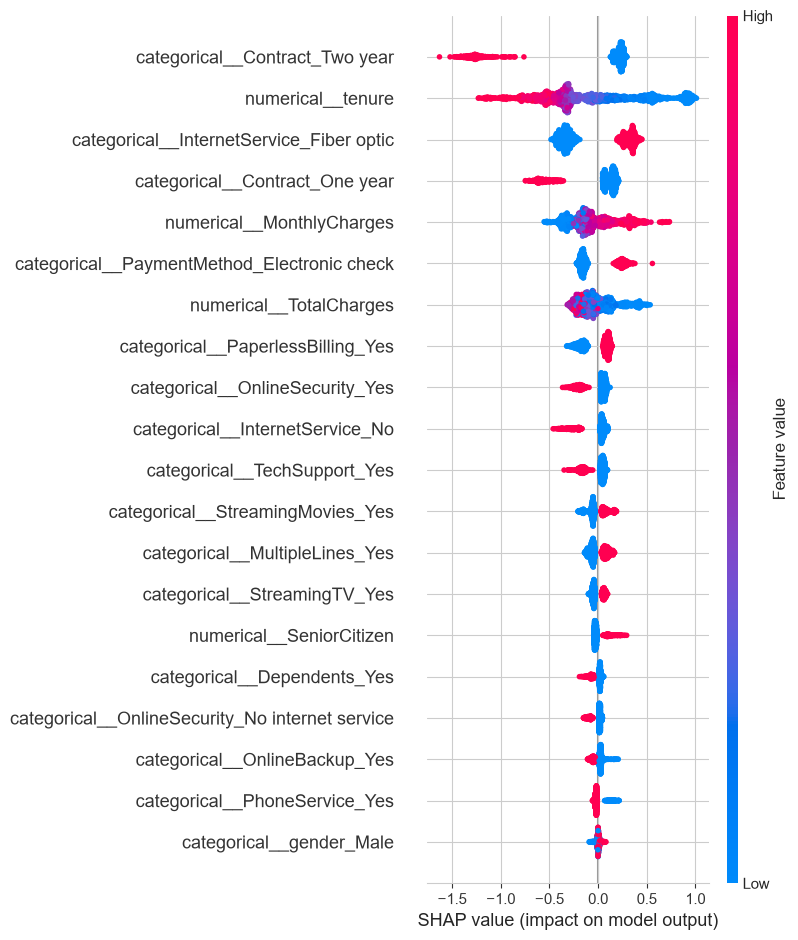

In [30]:
# ============================================================
# 30. SHAP ANALYSIS
# ============================================================

if "shap" in globals() and best_model_name in [
    "Tuned Random Forest",
    "Tuned XGBoost"
]:

    classifier = best_model.named_steps["classifier"]
    fitted_preprocessor = best_model.named_steps["preprocessor"]

    X_test_transformed = fitted_preprocessor.transform(X_test)

    feature_names = (
        fitted_preprocessor.get_feature_names_out()
    )

    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()

    X_test_shap = pd.DataFrame(
        X_test_transformed,
        columns=feature_names
    )

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_shap)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    elif len(np.asarray(shap_values).shape) == 3:
        shap_values_plot = shap_values[:, :, 1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(
        shap_values_plot,
        X_test_shap,
        max_display=20
    )


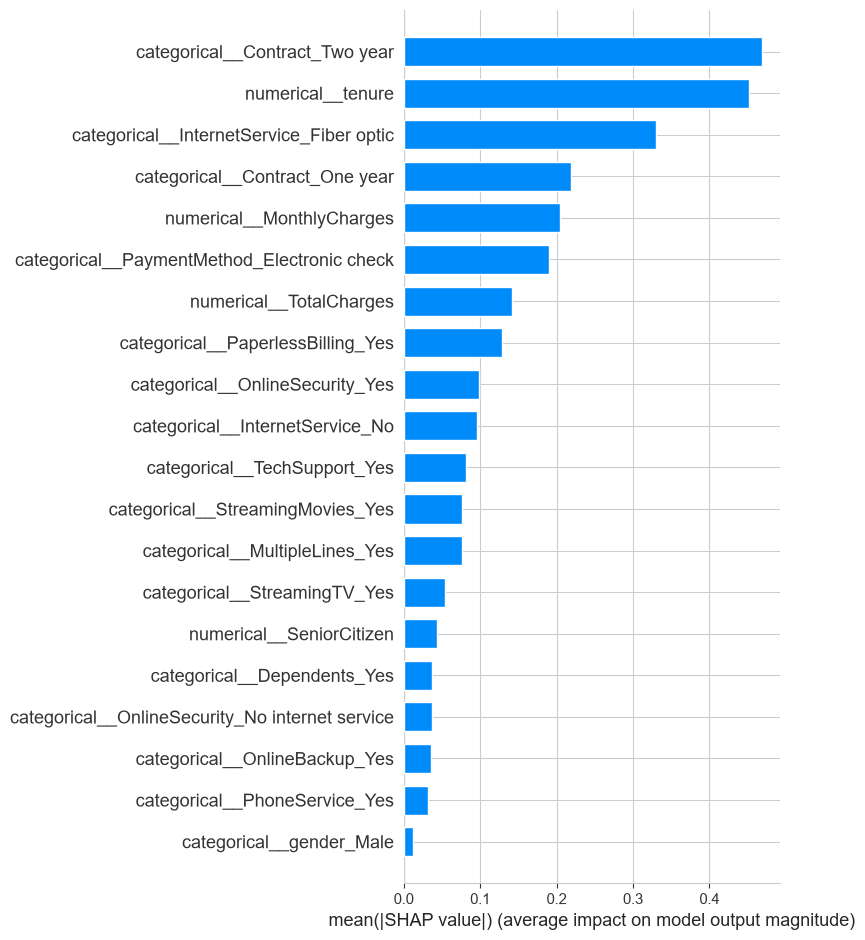

In [31]:
# ============================================================
# 31. SHAP FEATURE IMPORTANCE
# ============================================================

if (
    "shap_values_plot" in globals()
    and "X_test_shap" in globals()
):
    shap.summary_plot(
        shap_values_plot,
        X_test_shap,
        plot_type="bar",
        max_display=20
    )


In [32]:
# ============================================================
# 32. SAVE COMPLETE MODEL PIPELINE
# ============================================================

MODEL_FILE = "customer_churn_complete_pipeline.pkl"

with open(MODEL_FILE, "wb") as file:
    pickle.dump(best_model, file)

print(f"Model saved successfully as {MODEL_FILE}")


Model saved successfully as customer_churn_complete_pipeline.pkl


In [33]:
# ============================================================
# 33. SAVE MODEL METADATA
# ============================================================

metadata = {
    "model_name": best_model_name,
    "features": X.columns.tolist(),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "metrics": results.to_dict("records")
}

with open("customer_churn_metadata.pkl", "wb") as file:
    pickle.dump(metadata, file)

print("Metadata saved successfully.")


Metadata saved successfully.


In [34]:
# ============================================================
# 34. LOAD SAVED MODEL
# ============================================================

with open(
    "customer_churn_complete_pipeline.pkl",
    "rb"
) as file:
    loaded_model = pickle.load(file)

print("Saved model loaded successfully.")


Saved model loaded successfully.


In [35]:
# ============================================================
# 35. CUSTOMER CHURN PREDICTION FUNCTION
# ============================================================

def predict_customer_churn(customer_data):

    customer_df = pd.DataFrame([customer_data])

    prediction = loaded_model.predict(
        customer_df
    )[0]

    probability = loaded_model.predict_proba(
        customer_df
    )[0][1]

    if probability >= 0.75:
        risk = "High Risk"
    elif probability >= 0.50:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    return {
        "prediction": int(prediction),
        "churn_probability": float(probability),
        "risk_level": risk
    }


In [36]:
# ============================================================
# 36. TEST NEW CUSTOMER
# ============================================================

new_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}

prediction_result = predict_customer_churn(new_customer)

print("Prediction Result:")
print(prediction_result)


Prediction Result:
{'prediction': 1, 'churn_probability': 0.69975745677948, 'risk_level': 'Medium Risk'}


In [37]:
# ============================================================
# 37. HUMAN-READABLE PREDICTION
# ============================================================

result = prediction_result

print("=" * 60)
print("CUSTOMER CHURN PREDICTION")
print("=" * 60)

if result["prediction"] == 1:
    print("Prediction       : CUSTOMER LIKELY TO CHURN")
else:
    print("Prediction       : CUSTOMER LIKELY TO STAY")

print(
    f"Churn Probability: "
    f"{result['churn_probability']:.2%}"
)

print(
    f"Risk Level       : "
    f"{result['risk_level']}"
)

print("=" * 60)


CUSTOMER CHURN PREDICTION
Prediction       : CUSTOMER LIKELY TO CHURN
Churn Probability: 69.98%
Risk Level       : Medium Risk


In [38]:
# ============================================================
# 38. RETENTION RECOMMENDATION SYSTEM
# ============================================================

def generate_retention_recommendations(
    customer,
    churn_probability
):

    recommendations = []

    if customer["Contract"] == "Month-to-month":
        recommendations.append(
            "Offer a discounted annual or two-year contract."
        )

    if customer["tenure"] <= 6:
        recommendations.append(
            "Provide an early-tenure loyalty incentive."
        )

    if customer["InternetService"] == "Fiber optic":
        recommendations.append(
            "Review fiber-optic pricing and service quality."
        )

    if customer["TechSupport"] == "No":
        recommendations.append(
            "Offer a free trial of technical support."
        )

    if customer["PaymentMethod"] == "Electronic check":
        recommendations.append(
            "Offer automatic payment enrollment incentives."
        )

    if customer["MonthlyCharges"] > 70:
        recommendations.append(
            "Review pricing and offer a personalized plan."
        )

    if churn_probability >= 0.75:
        recommendations.append(
            "Prioritize this customer for immediate retention outreach."
        )
    elif churn_probability >= 0.50:
        recommendations.append(
            "Add this customer to the proactive retention campaign."
        )
    else:
        recommendations.append(
            "Continue regular customer engagement."
        )

    return recommendations


In [39]:
# ============================================================
# 39. GENERATE RETENTION RECOMMENDATIONS
# ============================================================

recommendations = generate_retention_recommendations(
    new_customer,
    prediction_result["churn_probability"]
)

print("Recommended Actions:\n")

for i, recommendation in enumerate(
    recommendations,
    start=1
):
    print(f"{i}. {recommendation}")


Recommended Actions:

1. Offer a discounted annual or two-year contract.
2. Provide an early-tenure loyalty incentive.
3. Offer a free trial of technical support.
4. Offer automatic payment enrollment incentives.
5. Add this customer to the proactive retention campaign.


In [40]:
# ============================================================
# 40. FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("CUSTOMER CHURN PREDICTION - FINAL SUMMARY")
print("=" * 70)

print(f"\nBest Model: {best_model_name}")

best_row = results.iloc[0]

print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1 Score : {best_row['F1 Score']:.4f}")
print(f"ROC-AUC  : {best_row['ROC-AUC']:.4f}")

print("\nModel saved as:")
print(MODEL_FILE)

print("\nProject pipeline:")
print(
    '''
    Data Collection
          ↓
    Data Cleaning
          ↓
    Exploratory Data Analysis
          ↓
    Train/Test Split
          ↓
    Feature Preprocessing
          ↓
    Stratified Cross Validation
          ↓
    Hyperparameter Tuning
          ↓
    Model Training
          ↓
    Model Evaluation
          ↓
    SHAP Explainability
          ↓
    Churn Probability
          ↓
    Customer Risk Segmentation
          ↓
    Retention Recommendations
    '''
)


CUSTOMER CHURN PREDICTION - FINAL SUMMARY

Best Model: Tuned XGBoost
Accuracy : 0.8041
Precision: 0.6667
Recall   : 0.5241
F1 Score : 0.5868
ROC-AUC  : 0.8485

Model saved as:
customer_churn_complete_pipeline.pkl

Project pipeline:

    Data Collection
          ↓
    Data Cleaning
          ↓
    Exploratory Data Analysis
          ↓
    Train/Test Split
          ↓
    Feature Preprocessing
          ↓
    Stratified Cross Validation
          ↓
    Hyperparameter Tuning
          ↓
    Model Training
          ↓
    Model Evaluation
          ↓
    SHAP Explainability
          ↓
    Churn Probability
          ↓
    Customer Risk Segmentation
          ↓
    Retention Recommendations
    
